# Hi-C basics — Drosophila S2 contact matrix with `epione.bulk.hic` / `epione.upstream`

End-to-end visual walk-through of `epione.bulk.hic` / `epione.upstream` on **real** Drosophila
*Schneider 2* (S2) cell Hi-C — the dataset the Galaxy HiCExplorer
tutorial uses [(Ramírez et al. 2018)][ramirez].
We start from the pre-built balanced `.cool` and show the canonical
Hi-C QC plots: genome-wide heatmap, single-chromosome zoom,
contact-decay P(s) curve, and per-bin coverage + ICE weight diagnostics.

Phase 2 / 3 tutorials (coming next) will build compartments (A/B via
eigendecomposition), TAD boundaries (insulation score), and loop
calls (dot-finder) on top of the same `.cool`.

### Upstream recipe (not run here — ~15 min wall-time)

The `.cool` used below was produced from the Galaxy Zenodo dataset
via the 4DN-standard `bwa mem -SP5M` + pairtools chain:

```bash
bwa index dm3_genome.fasta
bwa mem -SP5M -t 8 dm3_genome.fasta R1.fq.gz R2.fq.gz \
 | pairtools parse -c chrom.sizes --assembly dm3 --drop-sam --drop-seq --min-mapq 30 \
 | pairtools sort --nproc 8 \
 | pairtools dedup --mark-dups \
 | pairtools select "(pair_type=='UU') or (pair_type=='UR') or (pair_type=='RU')" \
      -o drosophila.pairs.gz
cooler cload pairs --assembly dm3 -c1 2 -p1 3 -c2 4 -p2 5 \
    chrom.sizes:10000 drosophila.pairs.gz drosophila.cool
```

In `epione.bulk.hic` / `epione.upstream` this maps to the Phase 1 API:

- `pairs_from_bam(...)` — runs the parse/sort/dedup/select chain.
  *(Not invoked here because it needs a real Hi-C BAM; replacing `bwa`
  with the existing `epi.upstream.bwa_mem2` binding is a Phase 2 task.)*
- `pairs_to_cool(pairs, sizes, out_cool, binsize=10_000)` — load pairs
  into a `.cool`.
- `balance_cool(out_cool)` — ICE balance in place.

[ramirez]: https://www.nature.com/articles/s41467-017-02525-w

### Dataset

Galaxy HiCExplorer tutorial `data-hic-drosophila` from
[Zenodo record 16416373](https://zenodo.org/records/16416373):

- `HiC_S2_1p_10min_lowU_R{1,2}.fastq.gz` (paired-end Hi-C from Kc167 S2 cells)
- `dm3_genome.fasta` — reference genome build dm3

On this run: 16 880 × 10 kb bins, 1.32 M non-zero pixels, 15 chromosomes.

## 1 · Setup

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cooler

import epione as epi
epi.pl.plot_set()

DATA = pathlib.Path('/scratch/users/steorra/data/drosophila-hic')
COOL = DATA / 'drosophila.cool'
assert COOL.exists(), (
    f'{COOL} missing — generate it once with the upstream recipe above '
    'or point COOL at your own .cool'
)

OUT = pathlib.Path('result') / 't_hic_basics'
OUT.mkdir(parents=True, exist_ok=True)

clr = cooler.Cooler(str(COOL))
print(f'bins      : {len(clr.bins()[:]):,}')
print(f'nnz pixels: {clr.pixels()[:].shape[0]:,}')
print(f'binsize   : {clr.binsize:,} bp')
print(f'chroms    : {list(clr.chromnames)}')

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

bins      : 16,880
nnz pixels: 1,317,818
binsize   : 10,000 bp
chroms    : ['chr2L', 'chr2LHet', 'chr2R', 'chr2RHet', 'chr3L', 'chr3LHet', 'chr3R', 'chr3RHet', 'chr4', 'chrU', 'chrUextra', 'chrX', 'chrXHet', 'chrYHet', 'chrM']


## 2 · Genome-wide contact matrix

Every `epione.bulk.hic` / `epione.upstream` plotting function reads the `.cool` directly via
`cooler`, so to render the whole genome we just pass `chrom=None` and
tick the chromosome boundaries by hand. For a quick overview we also
sum over chromosomes within a single heatmap to get the cis+trans
contact landscape.

genome-wide matrix: (16880, 16880) — finite cells: 164070481


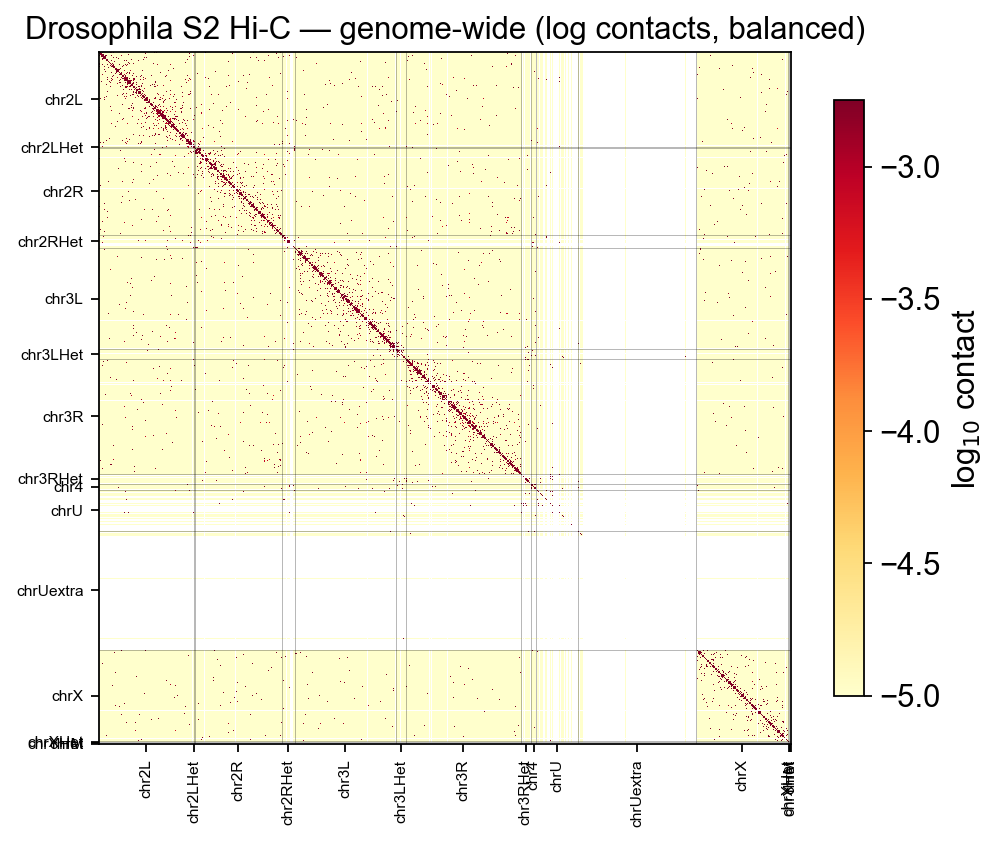

In [2]:
mat_gw = clr.matrix(balance=True)[:]
print('genome-wide matrix:', mat_gw.shape,
      '— finite cells:', int(np.isfinite(mat_gw).sum()))

fig, ax = plt.subplots(figsize=(6.5, 6))
from matplotlib.colors import LogNorm
vmax = float(np.nanquantile(mat_gw[np.isfinite(mat_gw)], 0.99))
img = ax.imshow(
    np.log10(mat_gw + 1e-5),
    origin='upper', cmap='YlOrRd',
    vmin=np.log10(max(vmax * 1e-4, 1e-5)), vmax=np.log10(vmax),
    interpolation='none',
)
# chromosome tick marks
chrom_edges = clr.offset(clr.chromnames[-1])
offsets = [clr.offset(c) for c in clr.chromnames]
mids = [(o + (offsets[i+1] if i+1 < len(offsets) else clr.shape[0])) / 2
        for i, o in enumerate(offsets)]
ax.set_xticks(mids)
ax.set_xticklabels(clr.chromnames, rotation=90, fontsize=7)
ax.set_yticks(mids)
ax.set_yticklabels(clr.chromnames, fontsize=7)
for o in offsets[1:]:
    ax.axvline(o, color='k', lw=0.25, alpha=0.5)
    ax.axhline(o, color='k', lw=0.25, alpha=0.5)
ax.set_title('Drosophila S2 Hi-C — genome-wide (log contacts, balanced)')
fig.colorbar(img, ax=ax, shrink=0.7, label=r'log$_{10}$ contact')
plt.tight_layout()
plt.show()

## 3 · Single-chromosome heatmap

`epi.bulk.hic.plot_contact_matrix` takes a UCSC-style region string. The
chr2L 23-Mb arm is the canonical chromosome for tutorials because
it fits comfortably in a single square and has well-studied Polycomb
/ chromatin domains visible as off-diagonal blocks.

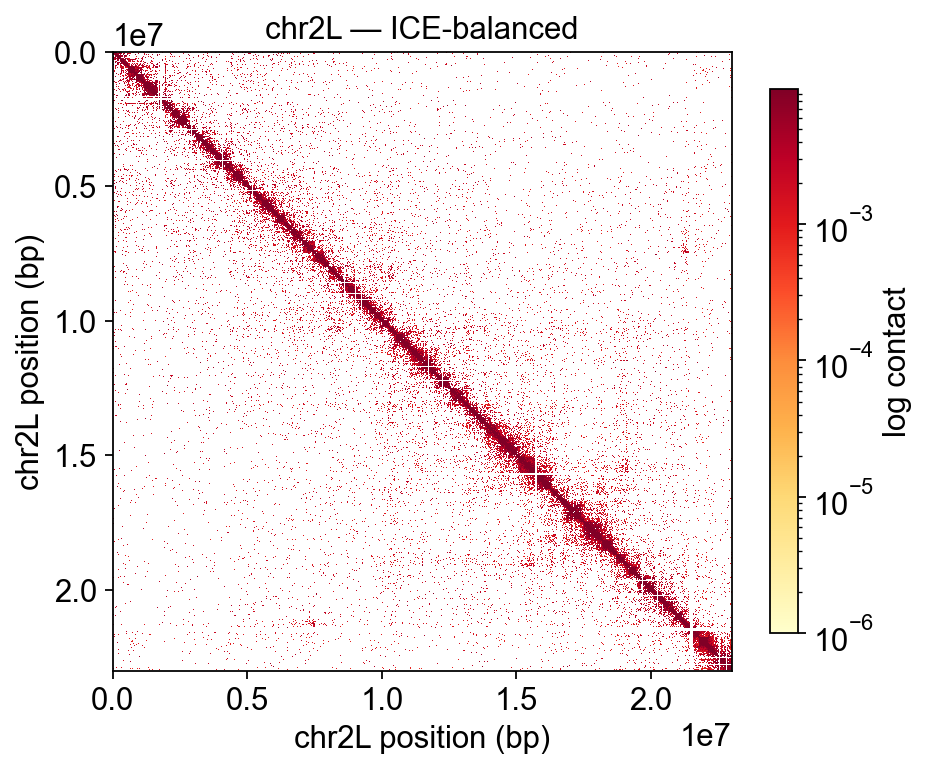

In [3]:
fig, ax, img = epi.pl.plot_contact_matrix(
    COOL, region='chr2L',
    balance=True, log=True,
    figsize=(6.2, 5.6),
    title='chr2L — ICE-balanced',
)
plt.show()

### 3.1 Zoom into a 3-Mb slice

Pan into a 3-Mb interval on chr2L so the off-diagonal "boxes"
characteristic of Drosophila TADs become visible. Phase 3 will
auto-detect the boundaries with insulation score; here we just eye
them.

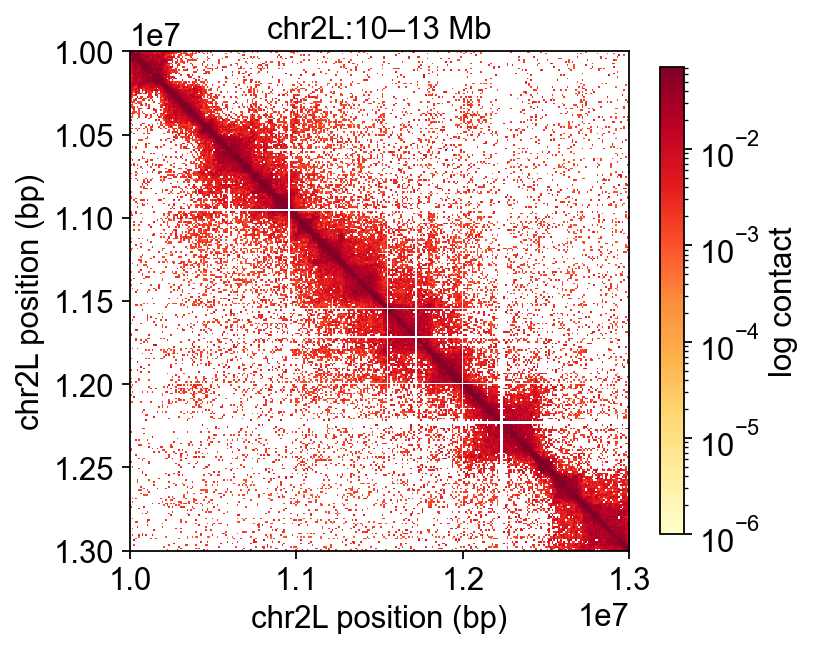

In [4]:
fig, ax, img = epi.pl.plot_contact_matrix(
    COOL, region='chr2L:10_000_000-13_000_000',
    balance=True, log=True,
    figsize=(5.0, 4.8),
    title='chr2L:10–13 Mb',
)
plt.show()

## 4 · Contact-decay curve P(s)

The most informative per-library QC plot. Average every intra-chrom
diagonal offset across all 15 chromosomes, plot on log-log axes.
A healthy Hi-C library decays roughly as a power-law with slope ~−1
over most of the dynamic range; a plateau, bump or non-monotone
shape points to undersampling, too-short fragment selection, or
over-balancing.

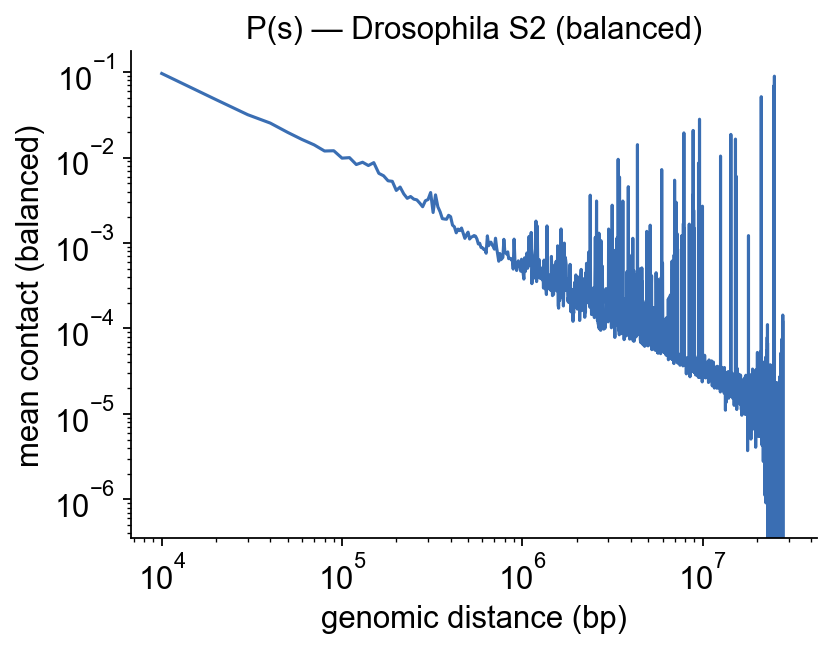

,chrom,offset_bin,distance_bp,mean_contact,n_pairs
0,chr2L,0,0,0.263320,2222
1,chr2L,1,10000,0.120140,2177
2,chr2L,2,20000,0.056927,2167
3,chr2L,3,30000,0.037639,2168
4,chr2L,4,40000,0.028203,2164
5,chr2L,5,50000,0.022670,2158
6,chr2L,6,60000,0.018948,2154
7,chr2L,7,70000,0.016106,2149
8,chr2L,8,80000,0.013840,2150
9,chr2L,9,90000,0.012063,2148


In [5]:
fig, ax, decay_df = epi.pl.plot_decay_curve(
    COOL, balance=True, figsize=(5.5, 4.0),
    title='P(s) — Drosophila S2 (balanced)',
)
plt.show()
decay_df.head(10)

## 5 · Per-bin coverage + ICE weight diagnostics

`plot_coverage` lays out two panels side-by-side: left = per-bin
total contact coverage (what ICE balance saw), right = per-bin
ICE weight (what balance emitted). Bins whose weight is NaN are
masked from the balanced matrix — typically low-mappability
regions, gaps, and heterochromatin repeats.

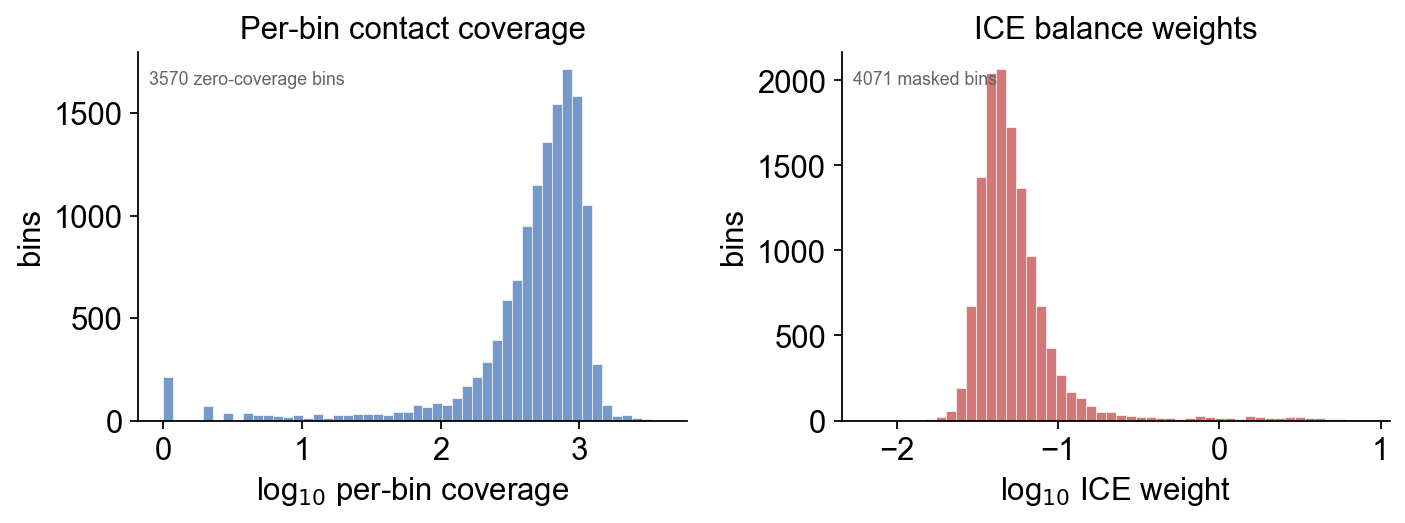

In [6]:
fig, axes = epi.pl.plot_coverage(
    COOL, balance=False, bins=50, figsize=(9, 3.5),
)
plt.show()

On the Drosophila S2 library: ~4 k bins are masked (no ICE weight),
almost all of them on the Het / U / Uextra unmappable regions that
dm3 pads with low-quality reference sequence. The rest of the
16.8 k bins retain balanced contacts.

## 6 · Summary + what's next

Phase 1 lands five `epione.bulk.hic` / `epione.upstream` entry points, all exercised above
against the Galaxy Drosophila dataset:

| Call | Role |
| --- | --- |
| `pairs_from_bam` | BAM → `.pairs.gz` (pairtools chain) |
| `pairs_to_cool` | `.pairs.gz` → `.cool` at chosen binsize |
| `balance_cool` | ICE-balance a `.cool` in place |
| `plot_contact_matrix` | log-scale region heatmap (chrom or interval) |
| `plot_decay_curve` | P(s) contact-decay curve |
| `plot_coverage` | per-bin coverage + ICE weight histograms |

Phase 2 (`t_hic_analysis.ipynb`) layers downstream analyses on top
of the same balanced `.cool`:

- **A / B compartments** via eigendecomposition (`hicPCA`-equivalent),
  with GC-content orientation.
- **TAD boundaries** via insulation score (`cooltools.insulation`).
- **Loop calling** via dot-finder (`cooltools.dots`).
- A composite *"Hi-C triangle + TAD boundaries + ChIP-seq tracks"*
  plot piped into the existing `epi.bulk.bigwig.plot_track_multi`.